# Final Project - STA4724

##### Naziat Chowdhury, Caitlin Box, Sameer Bashir, Mustaeen Ahmed

### Using a dataset containing water quality measurements from the Back-Bay National Wildlife Refuge in Virginia Beach, we aimed to answer the following questions:
* How well can a set of water quality predictors predict changes in dissolved oxygen levels?
* Which environmental variables most strongly determine dissolved oxygen in the dataset?
* Which environmental conditions increase the odds of dangerously low dissolved oxygen?
* Which environmental conditions correspond to high dissolved oxygen (DO) vs. low DO environments?

Through these questions, we can help people working at the wildlife refuge, by giving them insights on environmental conditions to watch out for to maintain levels of dissolved oxygen. Dissolved oxygen is necessary for aquatic life to thrive, and too much/too little of it can be harmful in aquatic environments.

##### We use the following methods to answer these questions:
* Multiple-Linear Regression (and comparing Mean Absolute Error)
* Random Forests
* K-Means Clustering
* Logistic Regression

In [167]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
import statsmodels.formula.api as smf
from scipy.stats import shapiro
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import statsmodels.api as sm

### How well can a set of water quality predictors predict changes in dissolved oxygen levels?

In [168]:
df = pd.read_csv("back-bay.csv")
df = df.drop([
    "Unit_Id",
    "Read_Date",
    "Time (24:00)",
    "Field_Tech",
    "DateVerified",
    "WhoVerified",
    "Air Temp (?F)",
    "Air Temp-Celsius",
    "Year"
], axis=1)

df = df.rename(columns={
    "Salinity (ppt)" : "Salinity",
    "Dissolved Oxygen (mg/L)" : "Dissolved_Oxygen",
    "pH (standard units)" : "pH",
    "Secchi Depth (m)" : "Secchi_Depth",
    "Water Depth (m)" : "Water_Depth",
    "Water Temp (?C)" : "Water_Temp",
    "AirTemp (C)" : "Air_Temp",
})

print(df.shape)
df.head()

(2371, 8)


,Site_Id,Salinity,Dissolved_Oxygen,pH,Secchi_Depth,Water_Depth,Water_Temp,Air_Temp
0,Bay,1.3,11.7,7.3,0.40,0.40,5.9,8.0
1,Bay,1.5,12.0,7.4,0.20,0.35,3.0,2.6
2,Bay,1.0,10.5,7.2,0.25,0.60,5.9,7.6
3,Bay,1.0,10.1,7.4,0.35,0.50,10.0,2.7
4,Bay,1.0,12.6,7.2,0.20,0.40,1.6,0.0


In [169]:
df["Site_Id"] = df["Site_Id"].astype("category")

df = df[df["Water_Temp"] <= 35]
df = df[df["Air_Temp"] <= 35]
df = df[df["Water_Temp"] > 0]
df = df[df["pH"] > 0.3]
df = df[df["Dissolved_Oxygen"] > 2]
df = df[df["Salinity"] < 9]

df = df.dropna() # drop all data points with missing values

df.shape

(1286, 8)

In [170]:
df.describe(include="all")

# summary of data

,Site_Id,Salinity,Dissolved_Oxygen,pH,Secchi_Depth,Water_Depth,Water_Temp,Air_Temp
count,1286,1286.000000,1286.000000,1286.000000,1286.000000,1286.000000,1286.000000,1286.000000
unique,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Bay,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,666,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.897970,6.826726,7.209603,0.498628,0.750556,17.753118,15.752663
std,NaN,1.321837,2.427621,0.780232,0.480942,0.579570,7.860031,10.049011
min,NaN,0.000000,2.200000,4.800000,0.000000,0.010000,1.000000,-17.777778
25%,NaN,0.000000,5.000000,6.500000,0.300000,0.450000,11.000000,8.888889
50%,NaN,0.000000,6.700000,7.000000,0.400000,0.680000,18.000000,16.666667
75%,NaN,1.500000,8.700000,7.500000,0.600000,0.900000,25.000000,23.888889


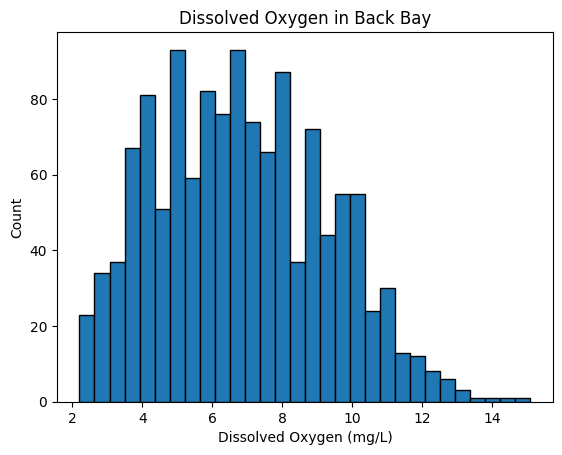

In [171]:
plt.figure()
plt.hist(df["Dissolved_Oxygen"], bins=30, edgecolor="k")
plt.xlabel("Dissolved Oxygen (mg/L)")
plt.ylabel("Count")
plt.title("Dissolved Oxygen in Back Bay")
plt.show()

In [172]:
columns_numeric = [
    "Salinity", "Dissolved_Oxygen", "pH", "Secchi_Depth", "Water_Depth", "Water_Temp", "Air_Temp"
]

df[columns_numeric].corr()

# correlation matrix of numeric columns

,Salinity,Dissolved_Oxygen,pH,Secchi_Depth,Water_Depth,Water_Temp,Air_Temp
Salinity,1.000000,0.387853,0.329143,-0.151235,-0.068264,-0.000546,0.077619
Dissolved_Oxygen,0.387853,1.000000,0.087146,-0.067435,-0.019854,-0.542948,-0.330632
pH,0.329143,0.087146,1.000000,-0.118637,-0.133882,0.198845,0.170777
Secchi_Depth,-0.151235,-0.067435,-0.118637,1.000000,0.850850,0.018684,-0.018513
Water_Depth,-0.068264,-0.019854,-0.133882,0.850850,1.000000,0.070690,0.047586
Water_Temp,-0.000546,-0.542948,0.198845,0.018684,0.070690,1.000000,0.699924
Air_Temp,0.077619,-0.330632,0.170777,-0.018513,0.047586,0.699924,1.000000


In [173]:
train, test = train_test_split(df, test_size=0.3, random_state=1)

print(train.shape)
test.shape

(900, 8)


(386, 8)

In [174]:
regular_formula = "Dissolved_Oxygen ~ Salinity + pH + Water_Temp + Water_Depth + Secchi_Depth + Air_Temp + C(Site_Id)" 
# regular multiple linear regression, no transformations or applied functions

# optimized models, to test which transformations/functions work better
log_water_formula = "Dissolved_Oxygen ~ Salinity + pH + np.log(Water_Temp) + C(Site_Id)" # log water
log_salinity_formula = "Dissolved_Oxygen ~ np.log(Salinity + 1) + pH + Water_Temp + C(Site_Id)" # as salinity is <1 in the dataset
temp_depth_interaction_formula = "Dissolved_Oxygen ~ Salinity + pH + Water_Temp * Water_Depth + C(Site_Id)" # interaction term, water depth and water temp

regular = smf.ols(formula=regular_formula, data=train).fit()
log_water = smf.ols(formula=log_water_formula, data=train).fit()
log_salinity = smf.ols(formula=log_salinity_formula, data=train).fit()
temp_depth = smf.ols(formula=temp_depth_interaction_formula, data=train).fit()

In [175]:
# get residuals and fitted values

regular_resid = regular.resid
regular_fitted = regular.fittedvalues

log_water_resid = log_water.resid
log_water_fitted = log_water.fittedvalues

log_salinity_resid = log_salinity.resid
log_salinity_fitted = log_salinity.fittedvalues

temp_depth_resid = temp_depth.resid
temp_depth_fitted = temp_depth.fittedvalues

In [176]:
# shapiro-wilk test, normality

regular_W, regular_p_value = shapiro(regular_resid)
print("Regular W = ", regular_W)
print("Regular p-value = ", regular_p_value)

log_water_W, log_water_p_value = shapiro(log_water_resid)
print("\nLog Water W = ", log_water_W)
print("Log Water p-value = ", log_water_p_value)

log_salinity_W, log_salinity_p_value = shapiro(log_salinity_resid)
print("\nLog Salinity W = ", log_salinity_W)
print("Log Salinity p-value = ", log_salinity_p_value)

temp_depth_W, temp_depth_p_value = shapiro(temp_depth_resid)
print("\nTemp x Depth W = ", temp_depth_W)
print("Temp x Depth p-value = ", temp_depth_p_value)

Regular W =  0.9967624670582925
Regular p-value =  0.06379500172946445

Log Water W =  0.997229636765699
Log Water p-value =  0.12726081126103583

Log Salinity W =  0.9956143444165674
Log Salinity p-value =  0.011540677255597591

Temp x Depth W =  0.996739949048909
Temp x Depth p-value =  0.0616869906986562


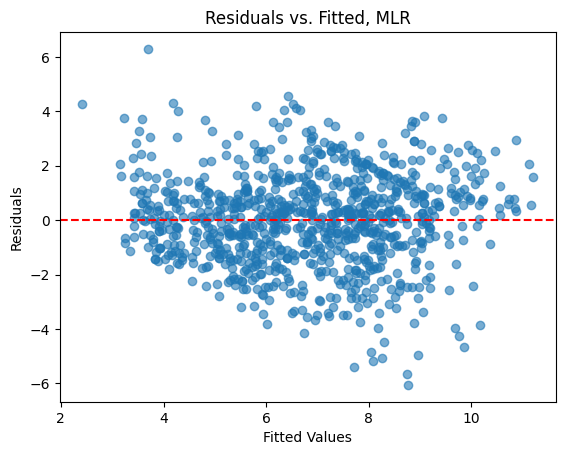

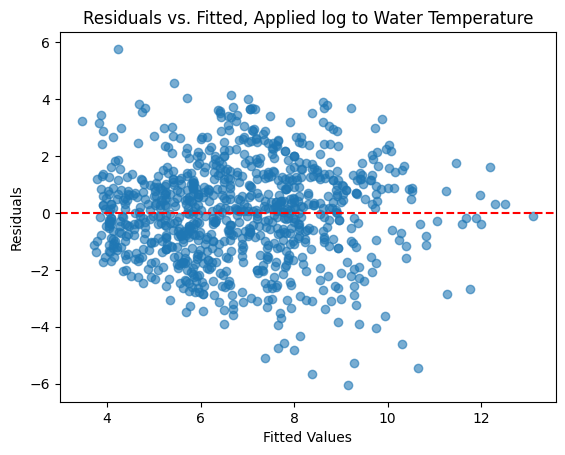

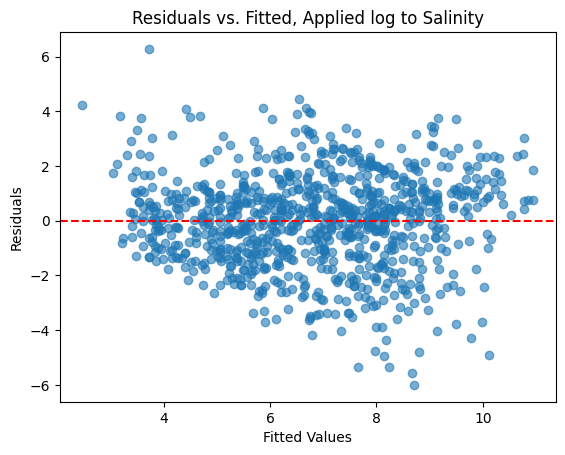

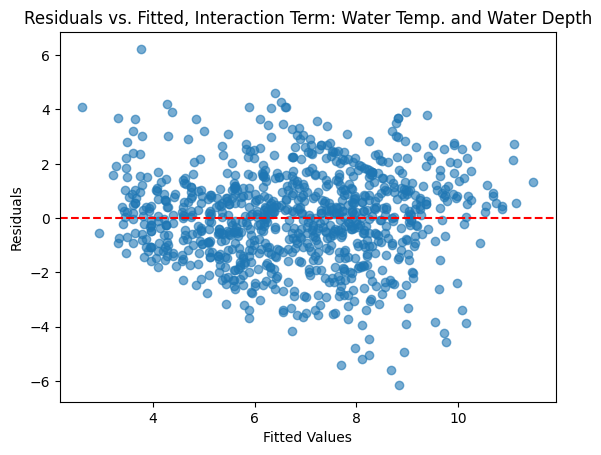

In [177]:
# residual vs fitted plots

plt.figure()
plt.scatter(regular_fitted, regular_resid, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.title("Residuals vs. Fitted, MLR")
plt.show()

plt.figure()
plt.scatter(log_water_fitted, log_water_resid, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.title("Residuals vs. Fitted, Applied log to Water Temperature")
plt.show()

plt.figure()
plt.scatter(log_salinity_fitted, log_salinity_resid, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.title("Residuals vs. Fitted, Applied log to Salinity")
plt.show()

plt.figure()
plt.scatter(temp_depth_fitted, temp_depth_resid, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.title("Residuals vs. Fitted, Interaction Term: Water Temp. and Water Depth")
plt.show()


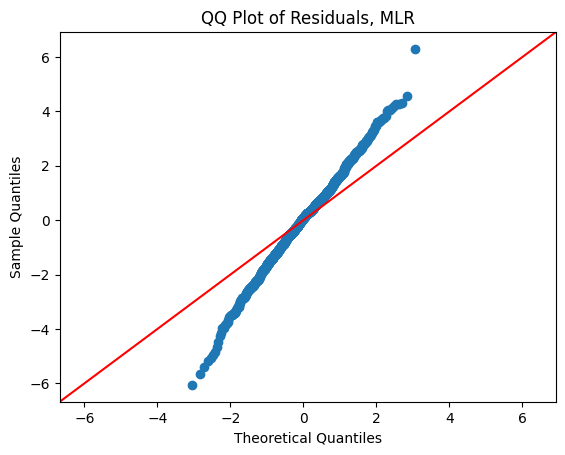

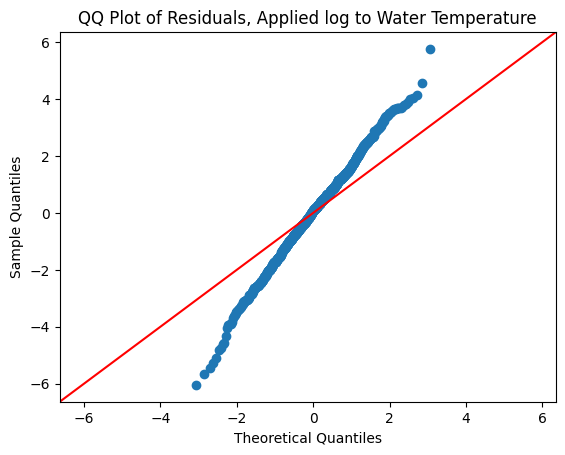

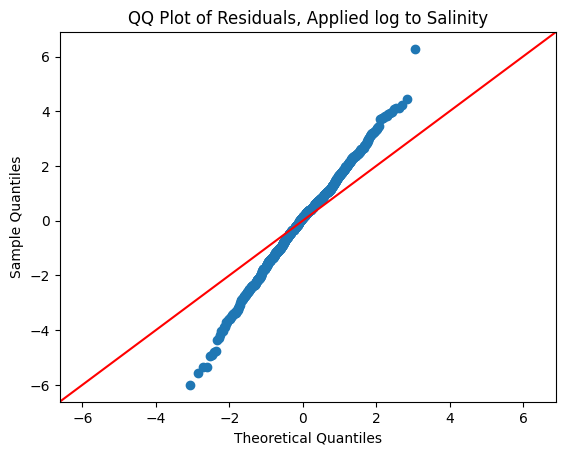

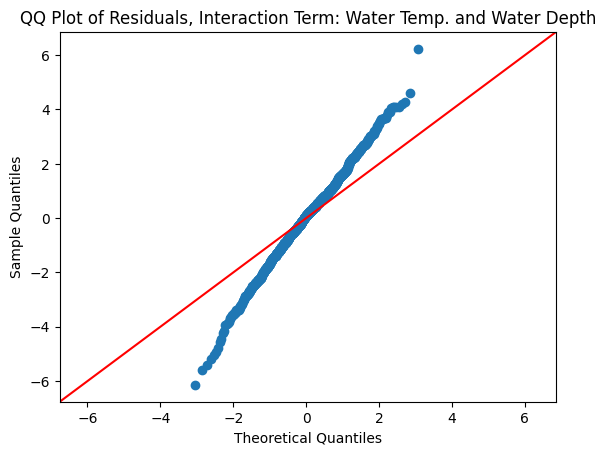

In [178]:
# qq plots of residuals

sm.qqplot(regular_resid, line="45")
plt.title("QQ Plot of Residuals, MLR")
plt.show()

sm.qqplot(log_water_resid, line="45")
plt.title("QQ Plot of Residuals, Applied log to Water Temperature")
plt.show()

sm.qqplot(log_salinity_resid, line="45")
plt.title("QQ Plot of Residuals, Applied log to Salinity")
plt.show()

sm.qqplot(temp_depth_resid, line="45")
plt.title("QQ Plot of Residuals, Interaction Term: Water Temp. and Water Depth")
plt.show()

In [179]:
# mean absolute error

regular_pred_train = regular.predict(train)
regular_pred_test = regular.predict(test)

regular_mae_train = mean_absolute_error(train["Dissolved_Oxygen"], regular_pred_train)
regular_mae_test = mean_absolute_error(test["Dissolved_Oxygen"], regular_pred_test)

print("MLR Train:", regular_mae_train)
print("MLR Test:", regular_mae_test)

log_water_pred_train = log_water.predict(train)
log_water_pred_test = log_water.predict(test)

log_water_mae_train = mean_absolute_error(train["Dissolved_Oxygen"], log_water_pred_train)
log_water_mae_test = mean_absolute_error(test["Dissolved_Oxygen"], log_water_pred_test)

print("\nLog Water MAE Train:", log_water_mae_train)
print("Log Water MAE Test:", log_water_mae_test)

log_salinity_pred_train = log_salinity.predict(train)
log_salinity_pred_test = log_salinity.predict(test)

log_salinity_mae_train = mean_absolute_error(train["Dissolved_Oxygen"], log_salinity_pred_train)
log_salinity_mae_test = mean_absolute_error(test["Dissolved_Oxygen"], log_salinity_pred_test)

print("\nLog Salinity MAE Train:", log_salinity_mae_train)
print("Log Salinity MAE Test:", log_salinity_mae_test)

temp_depth_pred_train = temp_depth.predict(train)
temp_depth_pred_test = temp_depth.predict(test)

temp_depth_mae_train = mean_absolute_error(train["Dissolved_Oxygen"], temp_depth_pred_train)
temp_depth_mae_test = mean_absolute_error(test["Dissolved_Oxygen"], temp_depth_pred_test)

print("\nTemp x Depth MAE Train:", temp_depth_mae_train)
print("Temp x Depth MAE Test:", temp_depth_mae_test)

MLR Train: 1.3341286833136292
MLR Test: 1.2814037564553038

Log Water MAE Train: 1.362370200004343
Log Water MAE Test: 1.3228028545462829

Log Salinity MAE Train: 1.3334465680981349
Log Salinity MAE Test: 1.2827315011405642

Temp x Depth MAE Train: 1.3347501413957914
Temp x Depth MAE Test: 1.2711110013726243


##### Among the three tested models, the `temp_depth` model gets the lowest MAE values, making it the best performing for predictive accuracy.

### Which environmental variables most strongly determine dissolved oxygen in the dataset?

In [180]:
rf_features = [
    "Salinity", "pH", "Secchi_Depth", "Water_Depth", "Water_Temp", "Air_Temp", "Site_Id"
]

X_train_rf = pd.get_dummies(train[rf_features], drop_first=True)
X_test_rf = pd.get_dummies(test[rf_features], drop_first=True) # prevent multicollinearity

X_train_rf.head()

,Salinity,pH,Secchi_Depth,Water_Depth,Water_Temp,Air_Temp,Site_Id_B,Site_Id_Bay,Site_Id_C,Site_Id_D,Site_Id_d
2109,0.0,6.5,0.20,0.40,16.0,15.555556,False,False,False,False,False
2030,0.0,9.0,0.50,0.80,27.0,27.222222,False,True,False,False,False
294,1.9,7.1,0.45,0.55,6.2,5.230000,False,True,False,False,False
17,1.0,8.6,0.35,0.80,23.8,25.700000,False,True,False,False,False
2084,0.0,6.5,0.90,1.30,14.0,8.888889,False,False,False,True,False


In [181]:
X_train_rf, X_test_rf = X_train_rf.align(X_test_rf, join="left", axis=1, fill_value=0)
# since site_id is categorical, ensure all site id levels are present in both datasets.
# similar to SQL LEFT JOIN

y_train = train["Dissolved_Oxygen"]
y_test = test["Dissolved_Oxygen"]

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=1,
    n_jobs=-1
)

rf.fit(X_train_rf, y_train)

rf_train_pred = rf.predict(X_train_rf)
rf_test_pred = rf.predict(X_test_rf)

rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_test_mae = mean_absolute_error(y_test, rf_test_pred)

print("Random Forest MAE Train:", rf_train_mae)
print("Random Forest MAE Test:", rf_test_mae)

# feature importance (ranked)
rf_importance = pd.Series(rf.feature_importances_, index=X_train_rf.columns).sort_values(ascending=False)

for feature, percent in rf_importance.items():
    print(f"{feature:<25}\t{percent * 100:.2f}%")

Random Forest MAE Train: 0.44195107407407475
Random Forest MAE Test: 1.2576959412780653
Water_Temp               	40.31%
Salinity                 	16.92%
Site_Id_Bay              	11.33%
Air_Temp                 	8.13%
Secchi_Depth             	7.63%
pH                       	7.00%
Water_Depth              	6.82%
Site_Id_D                	0.68%
Site_Id_B                	0.61%
Site_Id_C                	0.55%
Site_Id_d                	0.00%


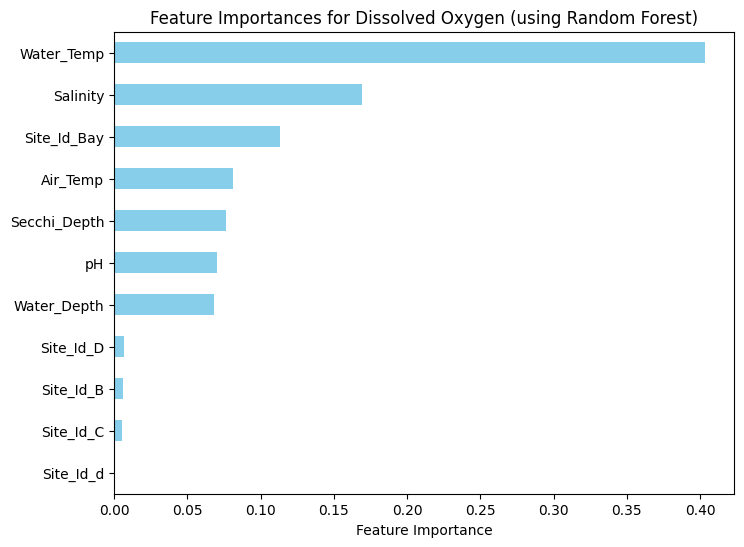

In [182]:
# graph ranking data of the variables

plt.figure(figsize=(8, 6))
rf_importance.sort_values().plot(kind='barh', color="skyblue")

plt.xlabel("Feature Importance")
plt.title("Feature Importances for Dissolved Oxygen (using Random Forest)")
plt.show()

##### The model performs well, given the considerably lower MAE value. We see that water temperature is by far the dominant factor in influencing dissolved oxygen. We also see that salinity and geographic location are the next most influential. Air temperature, water clarity (secchi depth), and pH also have a lesser, but notable contribution to DO.

### Which environmental conditions increase the odds of dangerously low dissolved oxygen?

In [183]:
train = train.copy()
test = test.copy()

# threshold, if dissolved oxygen is under 5.
train["low_do"] = (train["Dissolved_Oxygen"] < 5).astype(int)
test["low_do"] = (test["Dissolved_Oxygen"] < 5).astype(int)

log_reg_features = ["Water_Temp", "Salinity", "pH", "Site_Id"]

X_train_log_reg = pd.get_dummies(train[log_reg_features], drop_first=True)
X_test_log_reg = pd.get_dummies(test[log_reg_features], drop_first=True)

X_train_log_reg, X_test_log_reg = X_train_log_reg.align(X_test_log_reg, join="left", axis=1, fill_value=0)

y_train_log_reg = train["low_do"]
y_test_log_reg = test["low_do"]

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_log_reg, y_train_log_reg)

y_pred_log_reg = log_reg.predict(X_test_log_reg)
y_prob_log_reg = log_reg.predict_proba(X_test_log_reg)[:, 1]

coef_table = pd.DataFrame({
    "feature": X_train_log_reg.columns,
    "coefficient": log_reg.coef_[0]
})

coef_table.sort_values("coefficient")

,feature,coefficient
6,Site_Id_D,-1.300476
4,Site_Id_Bay,-1.230308
2,pH,-0.331016
5,Site_Id_C,-0.287550
1,Salinity,-0.260815
7,Site_Id_d,0.000000
3,Site_Id_B,0.065539
0,Water_Temp,0.184769


##### In this table, if a variable x is positive, then the higher x is, the higher the risk for dangerously low dissolved oxygen (DO). Conversely, if a variable x is negative, then the lower it is, the higher the risk for low DO.

##### We can see that high water temperature, low salinity, and low pH all increase the chance of dangerously low DO. Some specific locations also have a higher chance of low DO as well.

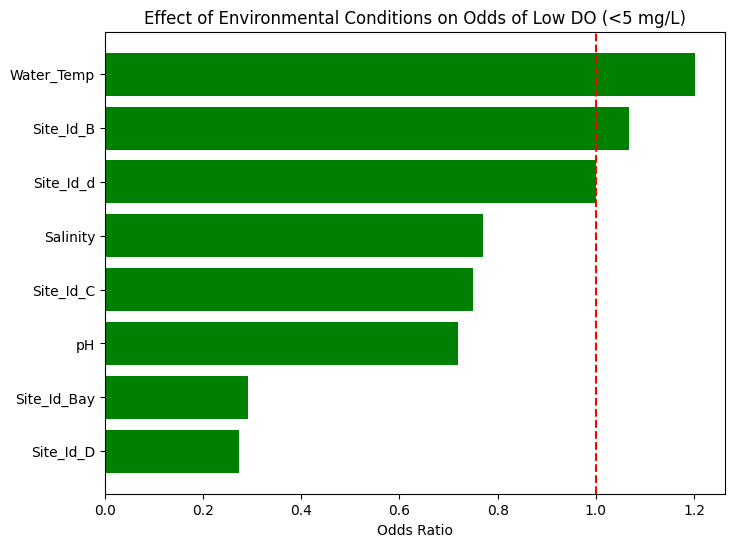

In [ ]:
coef = log_reg.coef_[0]
features = X_train_log_reg.columns
odds_ratios = np.exp(coef)

or_df = pd.DataFrame({"Feature": features, "OR": odds_ratios})
or_df = or_df.sort_values("OR", ascending=False)

plt.figure(figsize=(8,6))
plt.barh(or_df["Feature"], or_df["OR"], color="green")
plt.axvline(1, color="red", linestyle="--") # threshold of 1

plt.xlabel("Odds Ratio")
plt.title("Effect of Environmental Conditions on Odds of Low DO (<5 mg/L)")
plt.gca().invert_yaxis()
plt.show()

##### The bars above 1 increase low DO risk, while the bars below 1 decrease low DO risk.